# Backtrader Indicator Verification

In [19]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot
from pandas import read_csv

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.plots import curve, comparison
from lib.data import stats, ou
from lib.utils import extract_date_range
from lib import trading

# Config Plot Style
pyplot.style.use(config.glyfish_style)

In [20]:
def zscore_plot(zscore, zdate, window):
    title = f'USD.CAD Exchange Rate Z-Score: $t_{{1/2}} = {window:.0f}$ days'
    curve(zscore, zdate, title=title, xlabel=f"Day", ylabel="Z-Score", lw=1)

def zscore_indicator_plot(zscore, zdate, window):
    title = f'USD.CAD Exchange Rate Z-Score Indicator: $t_{{1/2}} = {window:.0f}$ days'
    curve(zscore, zdate, title=title, xlabel=f"Day", ylabel="Z-Score", lw=1)

def zscore_trading_plot(zscore, zdate, window):
    title = f'USD.CAD Exchange Rate Z-Score from Trading: $t_{{1/2}} = {window:.0f}$ days'
    curve(zscore, zdate, title=title, xlabel=f"Day", ylabel="Z-Score", lw=1)

def exchange_rate_plot(data, date):
    title = 'USD.CAD Exchange Rate'
    mean = numpy.full(len(data), numpy.mean(data))
    comparison([data, mean], date, title=title, xlabel="Date", ylabel="USD.CAD", labels=['USD.CAD', 'Mean'], lw=1)
    
def compute_mean_reversion_halflife(data):
    mean = numpy.full(len(data), numpy.mean(data))
    xt = data - mean
    result, result_model = ou.compute_mean_half_life_estimate(xt)
    return int(result_model.param_transforms[0].param.est), result

In [21]:
file_path = os.path.abspath('../../../data/algorithmic_trading/CAD=X.csv')
usd_cad_data = read_csv(file_path, index_col=0, parse_dates=True).sort_values(by='Date').dropna()
usd_cad_data.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2003-09-17,1.3667,1.3704,1.3636,1.3667,1.3667,0.0
2003-09-18,1.3660,1.3685,1.3597,1.3615,1.3615,0.0
2003-09-19,1.3620,1.3630,1.3457,1.3472,1.3472,0.0
2003-09-22,1.3413,1.3553,1.3365,1.3542,1.3542,0.0
2003-09-23,1.3549,1.3577,1.3458,1.3551,1.3551,0.0


In [22]:
date, usd_cad_close = extract_date_range(usd_cad_data.index.to_numpy(), usd_cad_data['Close'].to_numpy(), '2007-07-22', '2012-03-28')

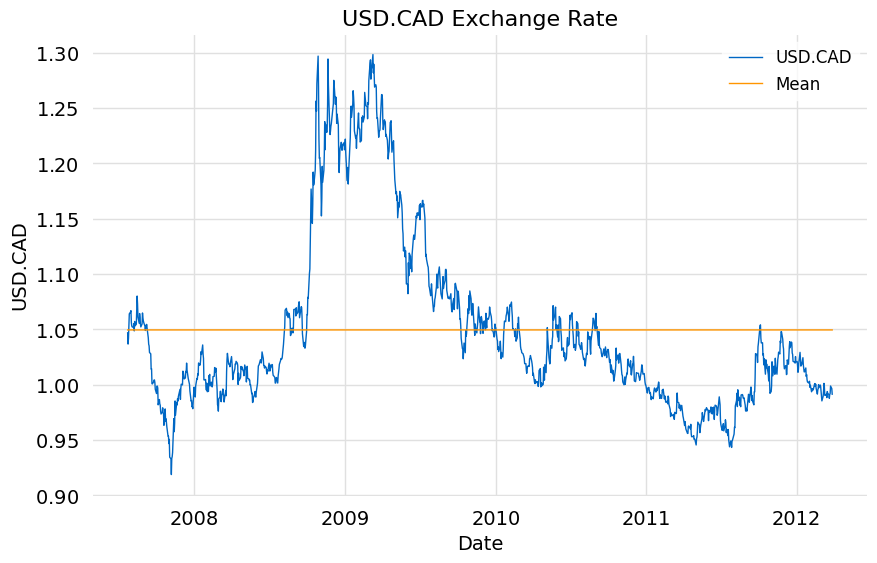

In [23]:
exchange_rate_plot(usd_cad_close, date)

## Mean Conversions Half-Life

The normalized deviation of the price, Z-Score, is defined by

$
\begin{align}
Z = \frac{y - \text{moving\_avg}(y, \text{halflife})}{\text{moving\_std}(y, \text{halflife})}
\end{align}
\tag{1}
$

where $\text{halflife}$ is the estimated mean reversion halflife of the time series. Two versions of the of a trading strategy using the Z-score will be investigated. For both strategies if $\text{Z-score} \gt 0$ a multiple of Z-score shares will be held. In the first tested strategy if $\text{Z-score} \lt 0$ all held shares will be sold and no purchases will be made until $\text{Z-score} \gt 0$. In the second version of the strategy the behavior for $\text{Z-score} \gt 0$ will be the same but if $\text{Z-score} \lt 0$ a short position consisting of a multiple of $-\text{Z-score}$ will be held.

### Mean Reversion Halflife

In [24]:
mean_reversion_half_life, result = compute_mean_reversion_halflife(usd_cad_close)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     3.256
Date:                Sun, 11 Feb 2024   Prob (F-statistic):             0.0714
Time:                        14:47:09   Log-Likelihood:                 4057.3
No. Observations:                1214   AIC:                            -8111.
Df Residuals:                    1212   BIC:                            -8100.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4.542e-05      0.000     -0.185      0.853      -0.001       0.000
x1            -0.0056      0.003     -1.804      0.071      -0.012       0.000
==============================================================================
Omnibus:                      113.415   Durbin-Watson:                   1.979
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              433.965
Skew:                           0.381   Prob(JB):                     5.83e-95
Kurtosis:                       5.828   Cond. No.                         12.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

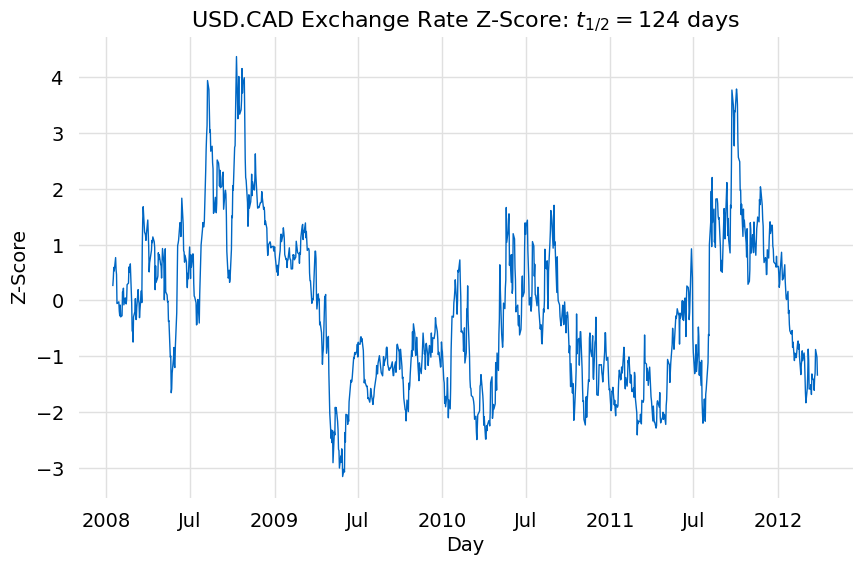

In [25]:
zdate, zscore = stats.compute_zscore(date, usd_cad_close, mean_reversion_half_life)
zscore_plot(zscore, zdate, mean_reversion_half_life)

## Z-Score Trading Strategy

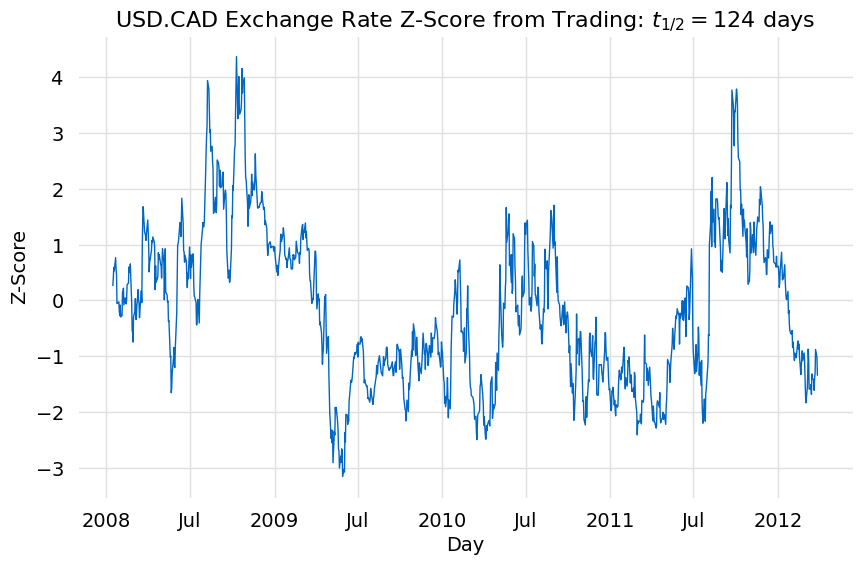

In [27]:
zdate, zscore = trading.compute_zscore(date, usd_cad_close, mean_reversion_half_life)
zscore_trading_plot(zscore, zdate, mean_reversion_half_life)

In [16]:
usd_cad_data[usd_cad_data.index >= '2007-07-23'].iloc[0:124].head(10)

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2007-07-23,1.04790,1.04790,1.04240,1.04676,1.04676,0.0
2007-07-24,1.04660,1.04726,1.03400,1.03660,1.03660,0.0
2007-07-25,1.03660,1.04455,1.03420,1.04180,1.04180,0.0
2007-07-26,1.04180,1.05680,1.04030,1.05360,1.05360,0.0
2007-07-27,1.05360,1.06530,1.05010,1.06390,1.06390,0.0
2007-07-30,1.06380,1.06980,1.06380,1.06556,1.06556,0.0
2007-07-31,1.06540,1.06786,1.05876,1.06680,1.06680,0.0
2007-08-01,1.06696,1.06970,1.05510,1.05600,1.05600,0.0
2007-08-02,1.05580,1.05950,1.05080,1.05300,1.05300,0.0


In [34]:
usd_cad_data[usd_cad_data.index >= '2007-07-23'].iloc[130:140]

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2008-01-24,1.02350,1.0253,1.0014,1.0043,1.0043,0.0
2008-01-25,1.00440,1.0096,1.0023,1.0041,1.0041,0.0
2008-01-28,1.00860,1.0118,1.0026,1.0046,1.0046,0.0
2008-01-29,1.00460,1.0064,0.9949,0.9983,0.9983,0.0
2008-01-30,0.99840,0.9994,0.9883,0.9950,0.9950,0.0
2008-01-31,0.99510,1.0081,0.9927,1.0013,1.0013,0.0
2008-02-01,1.00133,1.0030,0.9916,0.9936,0.9936,0.0
2008-02-04,0.99520,1.0008,0.9922,0.9939,0.9939,0.0
2008-02-05,0.99400,1.0082,0.9934,1.0080,1.0080,0.0


In [43]:
bt_file_path = os.path.abspath('../../../apps/output/getting_started.csv')
df = read_csv(bt_file_path)
df.fillna(0.0, inplace=True)

In [46]:
df.sma.to_numpy()

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 1.054     ,
       1.054     , 1.056     , 1.05866667, 1.06      , 1.06      ,
       1.05933333, 1.05866667, 1.05866667, 1.05866667, 1.05866667,
       1.05866667, 1.05866667, 1.05933333, 1.05933333, 1.06      ,
       1.06      , 1.05866667, 1.05666667, 1.05533333, 1.05466667,
       1.05333333, 1.052     , 1.05      , 1.04866667, 1.04733333,
       1.04466667, 1.04133333, 1.03733333, 1.03333333, 1.02933333,
       1.026     , 1.02266667, 1.01933333, 1.016     , 1.012     ,
       1.00933333, 1.00666667, 1.00466667, 1.00133333, 0.99866667,
       0.99666667, 0.99466667, 0.99333333, 0.99133333, 0.99      ,
       0.98866667, 0.98666667, 0.98466667, 0.982     , 0.98133333,
       0.97933333, 0.97733333, 0.97533333, 0.974     , 0.97133333,
       0.96933333, 0.96733333, 0.96533333, 0.96266667, 0.95933

In [45]:
df.columns

Index(['Id', 'CAD=X', 'len', 'datetime', 'open', 'high', 'low', 'close',
       'volume', 'openinterest', 'adjclose', 'TestStrategy', 'len.1',
       'datetime.1', 'MovingAverageSimple', 'len.2', 'sma', 'Broker', 'len.3',
       'cash', 'value', 'BuySell', 'len.4', 'buy', 'sell',
       'Trades - Net Profit/Loss', 'len.5', 'pnlplus', 'pnlminus'],
      dtype='object')

In [54]:
a = numpy.arange(10)
numpy.roll(a, 3), a

(array([7, 8, 9, 0, 1, 2, 3, 4, 5, 6]), array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]))